In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("scraped_quotes.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (50, 2)


,Quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


In [2]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Quote     0
Author    0
dtype: int64


In [3]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [4]:
# Check data types

print("Data types:")
print(df.dtypes)

Data types:
Quote     str
Author    str
dtype: object


In [5]:
# Basic statistics

print("Basic statistics:")
print(df.describe(include="all"))

Basic statistics:
                                                    Quote           Author
count                                                  50               50
unique                                                 50               28
top     “The world as we have created it is a process ...  Albert Einstein
freq                                                    1                8


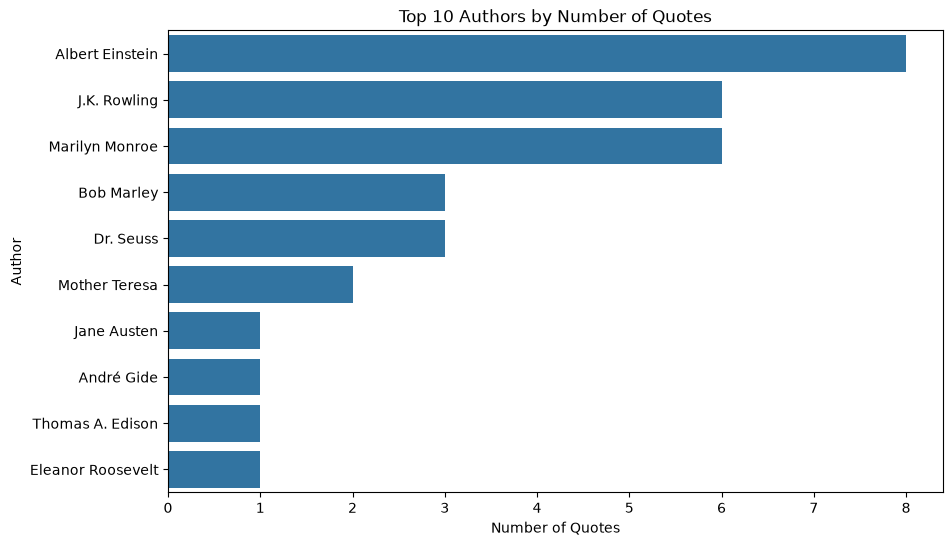

In [6]:
# Visualization 1: Top 10 authors by number of quotes

author_counts = df["Author"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df[df["Author"].isin(author_counts.index)],
    y="Author",
    order=author_counts.index
)

plt.title("Top 10 Authors by Number of Quotes")
plt.xlabel("Number of Quotes")
plt.ylabel("Author")
plt.show()

### Visualization 1 Interpretation

The count plot shows the 10 authors with the highest number of quotes in the scraped dataset. Albert Einstein appears most frequently among the authors. The chart also shows that the number of quotes varies across authors.

In [7]:
# Calculate quote length

df["Quote_Length"] = df["Quote"].str.len()

print("Average quote length:", round(df["Quote_Length"].mean(), 2))
print("Minimum quote length:", df["Quote_Length"].min())
print("Maximum quote length:", df["Quote_Length"].max())

Average quote length: 125.9
Minimum quote length: 34
Maximum quote length: 1084


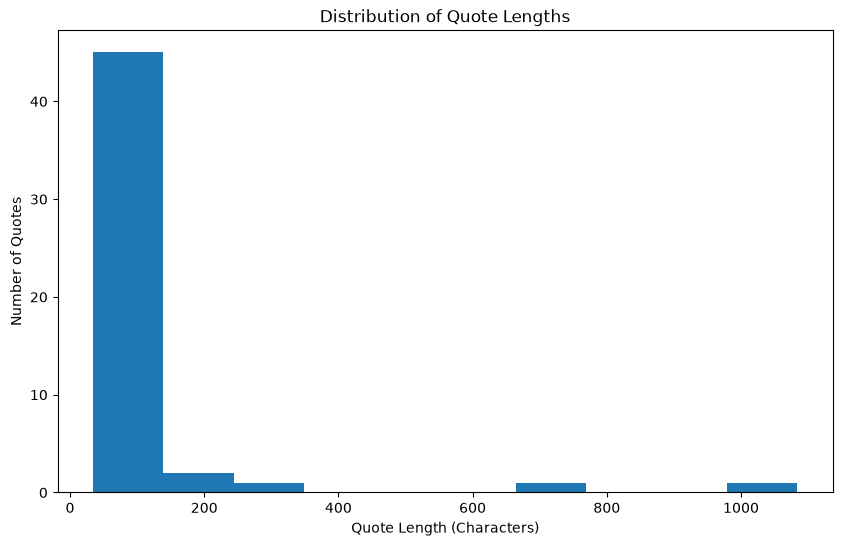

In [8]:
# Visualization 2: Quote length distribution

plt.figure(figsize=(10, 6))

plt.hist(df["Quote_Length"], bins=10)

plt.title("Distribution of Quote Lengths")
plt.xlabel("Quote Length (Characters)")
plt.ylabel("Number of Quotes")

plt.show()

### Visualization 2 Interpretation

The histogram shows the distribution of quote lengths in the scraped dataset. It helps identify whether the quotes are generally short or long and shows how frequently different quote-length ranges occur.

In [9]:
print("Average quote length:", round(df["Quote_Length"].mean(), 2))
print("Minimum quote length:", df["Quote_Length"].min())
print("Maximum quote length:", df["Quote_Length"].max())

Average quote length: 125.9
Minimum quote length: 34
Maximum quote length: 1084


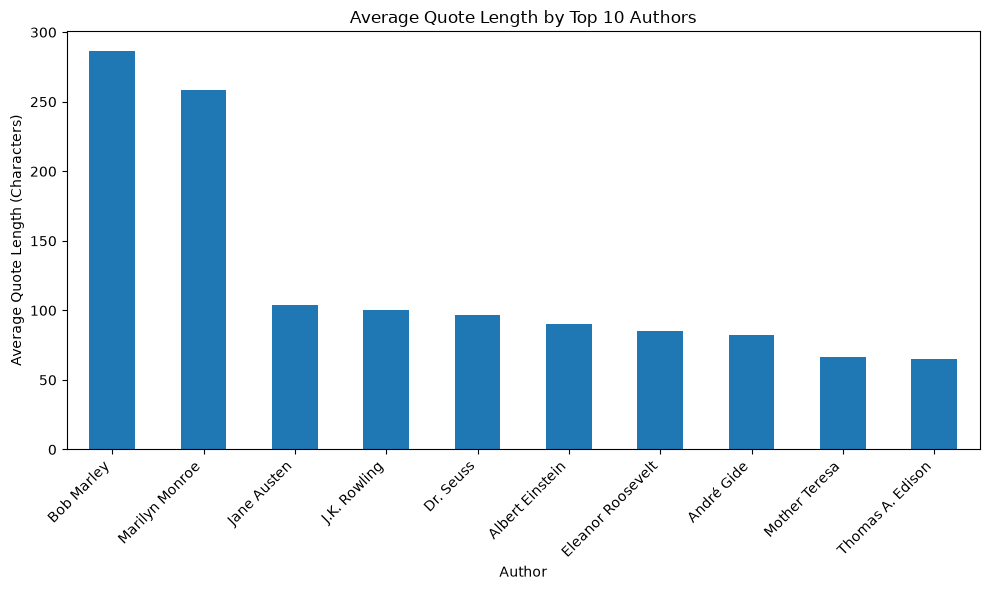

In [10]:
# Visualization 3: Average quote length by top 10 authors

top_authors = df["Author"].value_counts().head(10).index

author_avg_length = (
    df[df["Author"].isin(top_authors)]
    .groupby("Author")["Quote_Length"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

author_avg_length.plot(kind="bar")

plt.title("Average Quote Length by Top 10 Authors")
plt.xlabel("Author")
plt.ylabel("Average Quote Length (Characters)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Visualization 3 Interpretation

The bar chart compares the average quote length among the 10 most frequently occurring authors in the scraped dataset. The average quote length varies between authors, showing that some authors have longer quotes on average than others.

# Five Key Observations

1. The scraped dataset contains exactly 50 publicly available quotes from 28 unique authors.
2. There are no missing values or duplicate records in the scraped dataset.
3. Albert Einstein has the highest number of quotes in the dataset, with 8 quotes.
4. The average quote length is 125.9 characters, while the shortest quote is 34 characters and the longest is 1084 characters.
5. Quote lengths vary considerably between records, with most quotes being relatively short and a small number being much longer.

# Scraped Data Analysis Conclusion

The scraped dataset was successfully collected, cleaned and analyzed. The dataset contains 50 quotes and 28 unique authors, with no missing or duplicate records. Basic statistics and three visualizations were used to understand author frequency and quote-length patterns. The analysis shows variation in both the number of quotes contributed by authors and the lengths of the quotes.